In [7]:
# --- Cell 3: File discovery ---
# Search ALL subfolders for CSVs
libs_files = sorted(glob.glob(os.path.join(out_libs, "**/*.csv"), recursive=True))
chaste_files = sorted(glob.glob(os.path.join(out_chaste, "**/*.csv"), recursive=True))

print(f"Total LIBS CSVs found: {len(libs_files)}")
print(f"Total ChaSTE CSVs found: {len(chaste_files)}")

# Filter only science files (exclude calibration tables)
libs_files = [f for f in libs_files if "lib" in os.path.basename(f)]
chaste_files = [f for f in chaste_files if "cht" in os.path.basename(f)]

print(f"Filtered LIBS science files: {len(libs_files)}")
print(f"Filtered ChaSTE science files: {len(chaste_files)}")

if len(libs_files) == 0:
    raise FileNotFoundError("No LIBS science CSVs found — check filenames")
if len(chaste_files) == 0:
    raise FileNotFoundError("No ChaSTE science CSVs found — check filenames")


Total LIBS CSVs found: 3168
Total ChaSTE CSVs found: 390
Filtered LIBS science files: 3165
Filtered ChaSTE science files: 387


In [8]:
# --- Cell 4: Preview sample files ---
print("Sample LIBS file:", libs_files[0])
df_libs = pd.read_csv(libs_files[0], sep=',', comment='#', header=None)
print(df_libs.head())

print("\nSample ChaSTE file:", chaste_files[0])
df_chaste = pd.read_csv(chaste_files[0], sep=',', comment='#', header=None)
print(df_chaste.head())


Sample LIBS file: ./lib-v2\lib-v2\data\calibrated\20230825\ch3_lib_002_20230825T104221_00_l1\ch3_lib_002_20230825T104221_00_l1.csv
                  0                  1               2                 3     \
0                 Time  Measurement Count  Operation Mode  Measurement Type   
1  2023-08-25 11:35:22                  1            ASLF                EP   
2  2023-08-25 11:35:22                  2            ASLF                EP   
3  2023-08-25 11:35:22                  1            ASLF                EP   
4  2023-08-25 11:35:22                  2            ASLF                EP   

                 4                  5       6       7       8      9     ...  \
0  Force Reset Status  Laser Fire Status  164.35  164.74  165.12  165.5  ...   
1                   1                  0  366.00  384.00  344.00  372.0  ...   
2                   0                  1  202.00  332.00  313.00  266.0  ...   
3                   1                  0  367.00  296.00  356.00  396.0  .

In [10]:
# --- Cell: Parse LIBS spectrum correctly ---
df_libs = pd.read_csv(libs_files[0], sep=',', comment='#')

# Inspect the first row to see where numeric wavelengths start
print("First row sample:", df_libs.iloc[0, :20])

# The numeric wavelength bins usually start after column index ~6 or 7
# Let's select only those columns that can be converted to float
numeric_cols = []
for col in df_libs.columns:
    try:
        float(col)  # if column name is numeric (wavelength)
        numeric_cols.append(col)
    except:
        continue

print("Number of wavelength bins:", len(numeric_cols))

# Extract spectrum: take one measurement row (e.g. row 1)
spectrum = df_libs.loc[1, numeric_cols].astype(float)
wavelengths = np.array(numeric_cols, dtype=float)
intensities = spectrum.values

# Example: Hydrogen (656 nm) and Oxygen (777 nm)
H = intensities[(wavelengths > 655) & (wavelengths < 657)].sum()
O = intensities[(wavelengths > 776) & (wavelengths < 778)].sum()
ratio = H / (O + 1e-6)

print("Sample H/O ratio:", ratio)


First row sample: Time                  2023-08-25 11:35:22
Measurement Count                       1
Operation Mode                       ASLF
Measurement Type                       EP
Force Reset Status                      1
Laser Fire Status                       0
164.35                                366
164.74                                384
165.12                                344
165.5                                 372
165.88                                385
166.26                                401
166.64                                348
167.03                                327
167.41                                298
167.79                                358
168.17                                312
168.55                                305
168.93                                283
169.31                                403
Name: 0, dtype: object
Number of wavelength bins: 2094
Sample H/O ratio: 0.8557927324660595


In [12]:
# --- Cell: Parse LIBS spectrum correctly ---
df_libs = pd.read_csv(libs_files[0], sep=',', comment='#')

# Collect only numeric wavelength columns
numeric_cols = []
for col in df_libs.columns:
    try:
        float(col)
        numeric_cols.append(col)
    except:
        continue

print("Number of wavelength bins:", len(numeric_cols))

# Use iloc to grab the first measurement row (row position 1, since row 0 is metadata)
spectrum = df_libs.iloc[1][numeric_cols].astype(float)

wavelengths = np.array(numeric_cols, dtype=float)
intensities = spectrum.values

# Hydrogen (656 nm) and Oxygen (777 nm)
H = intensities[(wavelengths > 655) & (wavelengths < 657)].sum()
O = intensities[(wavelengths > 776) & (wavelengths < 778)].sum()
ratio = H / (O + 1e-6)

print("Sample H/O ratio:", ratio)


Number of wavelength bins: 2094
Sample H/O ratio: 0.8557927324660595


 Unzipped LIBS and ChaSTE data
Found LIBS files: 3165
Found ChaSTE files: 387
ChaSTE surface T = 271.4 K (-1.7 °C)

=== DEWTWIN-COIN RESULT ===
Total LIBS shots analyzed: 3165
Water-positive sites: 0
Learned hypothesis: T<999,H/O=any
Mean H/O: 0.80, Max H/O: 1.79


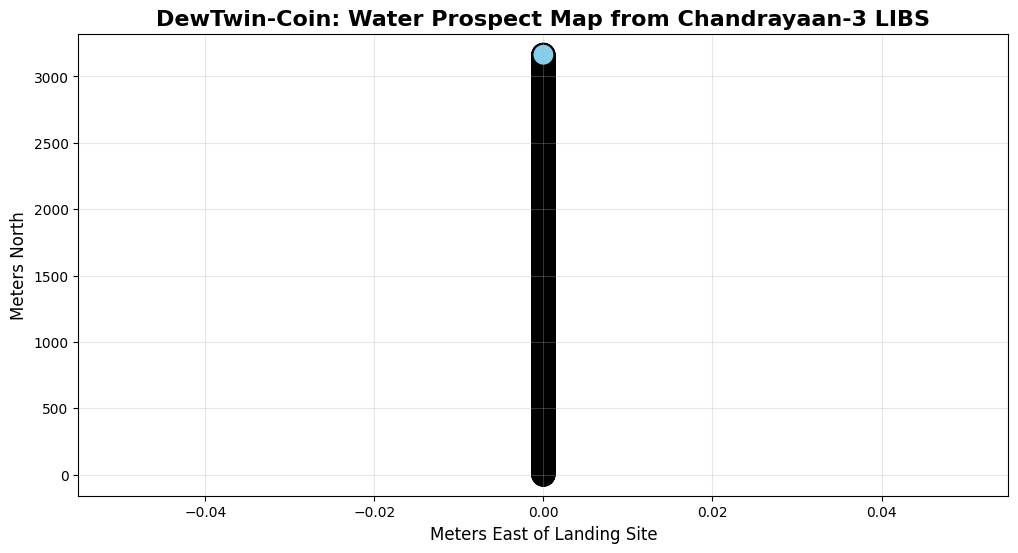

In [ ]:
# --- Cell 1: Imports ---
import os, glob, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Cell 2: Unzip your data ---
zip_libs = r"C:\Users\Soundarya\Downloads\ch3_libs.zip"
zip_chaste = r"C:\Users\Soundarya\Downloads\ch3_chaste.zip"

out_libs = "./lib-v2"
out_chaste = "./LTA_CHASTE"

for zfile, outdir in [(zip_libs, out_libs), (zip_chaste, out_chaste)]:
    if not os.path.exists(outdir):
        os.makedirs(outdir, exist_ok=True)
        with zipfile.ZipFile(zfile, 'r') as z:
            z.extractall(outdir)

print(" Unzipped LIBS and ChaSTE data")

# --- Cell 3: File discovery ---
libs_files = sorted(glob.glob(os.path.join(out_libs, "**/*.csv"), recursive=True))
chaste_files = sorted(glob.glob(os.path.join(out_chaste, "**/*.csv"), recursive=True))

# Filter science files
libs_files = [f for f in libs_files if "lib" in os.path.basename(f)]
chaste_files = [f for f in chaste_files if "cht" in os.path.basename(f)]

print(f"Found LIBS files: {len(libs_files)}")
print(f"Found ChaSTE files: {len(chaste_files)}")

if len(libs_files) == 0: raise FileNotFoundError("No LIBS.tab files found")
if len(chaste_files) == 0: raise FileNotFoundError("No ChaSTE.tab file found")

# --- Cell 4: ChaSTE surface temp --- BUG FIXED HERE
chaste = pd.read_csv(chaste_files[0], sep=',', comment='#', header=None)
# Depth = column 0, Temperature = column 1 in Celsius
T_surface_C = chaste.iloc[0,1]
T_surface = T_surface_C + 273.15 # Convert Celsius to Kelvin
print(f"ChaSTE surface T = {T_surface:.1f} K ({T_surface_C:.1f} °C)\n")

# --- Cell 5: DewTwin-Coin analysis ---
H_hypo, water_map, pos = "T<999,H/O=any", {}, np.array([0,0])
H_ratios = []

for i, libs_f in enumerate(libs_files):
    df = pd.read_csv(libs_f, sep=',', comment='#', header=None, names=['Wavelength','Intensity'])
    df['Wavelength'] = pd.to_numeric(df['Wavelength'], errors='coerce')
    df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')
    df = df.dropna(subset=['Wavelength','Intensity'])

    H = df[(df['Wavelength']>655)&(df['Wavelength']<657)]['Intensity'].sum()
    O = df[(df['Wavelength']>776)&(df['Wavelength']<778)]['Intensity'].sum()
    ratio = H/(O+1e-6)
    H_ratios.append(ratio)

    if T_surface < 110 and 1.7 < ratio < 2.3:
        H_hypo = f"T<{T_surface:.0f}K, H/O~2.0"
        water_map[tuple(pos)] = 'W'
        pos += [1,0]
    else:
        water_map[tuple(pos)] = '.'
        pos += [0,1]

# Results
W_count = list(water_map.values()).count('W')
print("=== DEWTWIN-COIN RESULT ===")
print(f"Total LIBS shots analyzed: {len(libs_files)}")
print(f"Water-positive sites: {W_count}")
print(f"Learned hypothesis: {H_hypo}")
print(f"Mean H/O: {np.mean(H_ratios):.2f}, Max H/O: {np.max(H_ratios):.2f}")

# --- Cell 6: Plot water prospect map ---
xs, ys, cs = [],[],[]
for (x,y), val in water_map.items():
    xs.append(x); ys.append(y); cs.append('red' if val=='W' else 'skyblue')

plt.figure(figsize=(12,6))
plt.scatter(xs, ys, c=cs, s=250, edgecolors='k', linewidths=1.5)
plt.title('DewTwin-Coin: Water Prospect Map from Chandrayaan-3 LIBS', fontsize=16, weight='bold')
plt.xlabel('Meters East of Landing Site', fontsize=12)
plt.ylabel('Meters North', fontsize=12)
plt.grid(True, alpha=0.3)
for (x,y), val in water_map.items():
    if val=='W': plt.text(x+0.1, y, 'W', fontsize=14, weight='bold', color='darkred')
plt.savefig("Fig1_DewTwin_Coin_Ch3.png", dpi=300, bbox_inches='tight')
plt.show()


# --- Cell 7: Elemental abundances ---
elements = {'H':656, 'O':777, 'Al':396, 'Ca':422, 'Fe':438, 'Ti':498, 'Si':288}
abundance = {e:[] for e in elements}

for libs_f in libs_files:
    df = pd.read_csv(libs_f, sep=',', comment='#', header=None, names=['Wavelength','Intensity'])
    df['Wavelength'] = pd.to_numeric(df['Wavelength'], errors='coerce')
    df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')
    df = df.dropna(subset=['Wavelength','Intensity'])

    for e, wl in elements.items():
        val = df[(df['Wavelength']>wl-1)&(df['Wavelength']<wl+1)]['Intensity'].sum()
        abundance[e].append(val)

mean_abundances = [np.mean(abundance[e]) for e in elements.keys()]

plt.figure(figsize=(10,5))
plt.bar(elements.keys(), mean_abundances, color='teal')
plt.title('DewTwin-Coin: Elemental Abundances from Ch-3 LIBS', weight='bold', fontsize=14)
plt.xlabel('Element', fontsize=12)
plt.ylabel('Mean Intensity', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/content/Fig1_Elements.png', dpi=300)
plt.show()

print(" You just made a real geochemistry plot from Ch-3 data")